# Lesson 5D: Options Pricing Models

**Probability, Statistics, Econometrics, and Finance**  
**Placement:** after Lesson 5C on consumption-based and production-based asset pricing.

This lecture introduces the theory and computation of option pricing. The goal is to connect economic logic, stochastic calculus, no-arbitrage pricing, dynamic hedging, and numerical implementation.

## Learning goals

By the end of this lecture, you should be able to:

1. Define calls, puts, moneyness, intrinsic value, time value, and common option strategies.
2. Draw and interpret option payoff and profit diagrams.
3. Derive and apply put-call parity.
4. Explain no-arbitrage pricing and risk-neutral valuation.
5. Understand the binomial option pricing model.
6. Explain stochastic calculus basics: Brownian motion, geometric Brownian motion, Itô's lemma, and the Black-Scholes PDE.
7. Derive and implement the Black-Scholes formula.
8. Compute and interpret the Greeks: delta, gamma, vega, theta, and rho.
9. Explain dynamic hedging and why option pricing does not require knowing the expected stock return.
10. Compute implied volatility.
11. Understand implied volatility smiles, skews, and surfaces.
12. Introduce stochastic volatility models such as Heston.
13. Introduce jump-diffusion models such as Merton.
14. Use Monte Carlo simulation for option pricing.
15. Understand the basic idea of model calibration to market prices.

The organizing principle is:

> An option price is the no-arbitrage cost of replicating, or risk-neutrally discounting, a state-contingent payoff.

In [1]:
# Core imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from math import log, sqrt, exp
from scipy.stats import norm
from scipy.optimize import brentq, minimize

np.random.seed(42)

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 120)

## 1. What Is an Option?

An option is a financial derivative. Its value is derived from the value of an underlying asset.

A **call option** gives its holder the right, but not the obligation, to buy the underlying asset at a fixed strike price $K$.

A **put option** gives its holder the right, but not the obligation, to sell the underlying asset at a fixed strike price $K$.

Important terms:

- $S_t$: underlying asset price at time $t$.
- $K$: strike price.
- $T$: expiration date.
- $r$: continuously compounded risk-free rate.
- $\sigma$: volatility of the underlying asset.
- $C$: call price.
- $P$: put price.

For a European option, exercise occurs only at maturity. For an American option, exercise may occur at or before maturity.

At maturity, a European call pays

$$
C_T = \max(S_T-K,0).
$$

A European put pays

$$
P_T = \max(K-S_T,0).
$$

The payoff is nonlinear. That nonlinearity is what makes options powerful and difficult to price.

## 2. Payoff Diagrams

The payoff of an option at expiration is determined by the terminal stock price $S_T$.

A long call payoff is

$$
\max(S_T-K,0).
$$

A long put payoff is

$$
\max(K-S_T,0).
$$

The **profit** subtracts the initial option premium. If a call costs $C_0$, then call profit at expiration is

$$
\max(S_T-K,0)-C_0.
$$

If a put costs $P_0$, then put profit is

$$
\max(K-S_T,0)-P_0.
$$

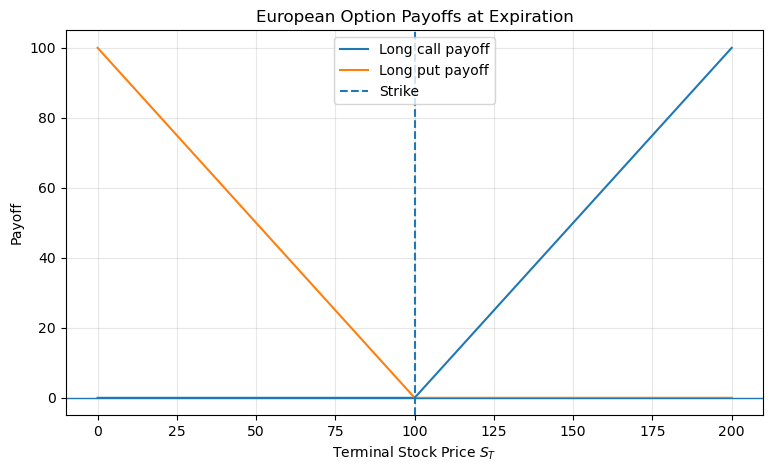

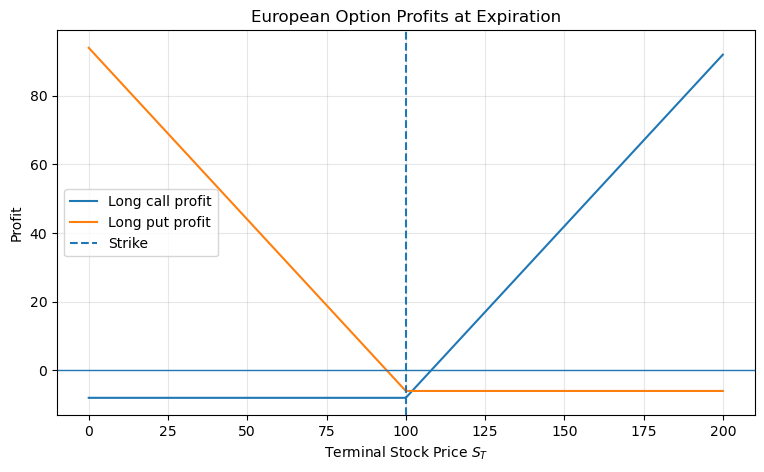

In [3]:
# Basic payoff diagrams

S = np.linspace(0, 200, 500)
K = 100
call_premium = 8
put_premium = 6

call_payoff = np.maximum(S - K, 0)
put_payoff = np.maximum(K - S, 0)

call_profit = call_payoff - call_premium
put_profit = put_payoff - put_premium

plt.figure(figsize=(9, 5))
plt.plot(S, call_payoff, label="Long call payoff")
plt.plot(S, put_payoff, label="Long put payoff")
plt.axhline(0, linewidth=1)
plt.axvline(K, linestyle="--", label="Strike")
plt.title("European Option Payoffs at Expiration")
plt.xlabel("Terminal Stock Price $S_T$")
plt.ylabel("Payoff")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(S, call_profit, label="Long call profit")
plt.plot(S, put_profit, label="Long put profit")
plt.axhline(0, linewidth=1)
plt.axvline(K, linestyle="--", label="Strike")
plt.title("European Option Profits at Expiration")
plt.xlabel("Terminal Stock Price $S_T$")
plt.ylabel("Profit")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 3. Common Option Strategies

Options can be combined to form payoff structures.

### Covered call

Own the stock and sell a call:

$$
S_T - \max(S_T-K,0).
$$

This sacrifices upside beyond $K$ in exchange for the call premium.

### Protective put

Own the stock and buy a put:

$$
S_T+\max(K-S_T,0).
$$

This creates downside protection.

### Bull call spread

Buy a call with a low strike $K_1$ and sell a call with a high strike $K_2$:

$$
\max(S_T-K_1,0)-\max(S_T-K_2,0).
$$

This creates limited upside and limited downside.

### Straddle

Buy a call and a put with the same strike:

$$
\max(S_T-K,0)+\max(K-S_T,0).
$$

This benefits from large moves in either direction.

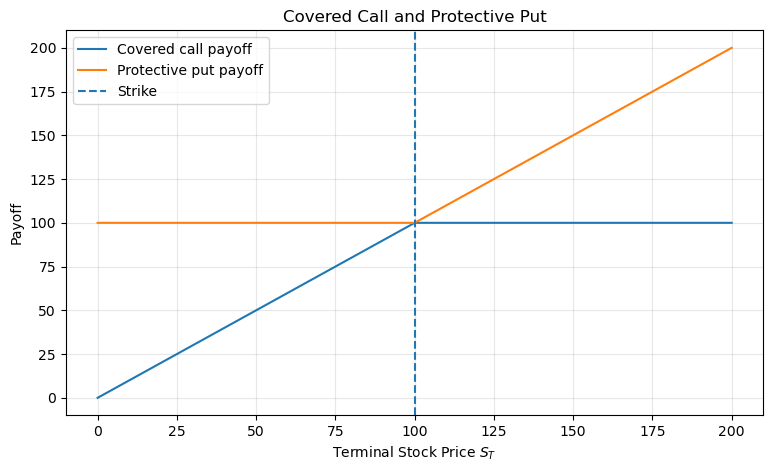

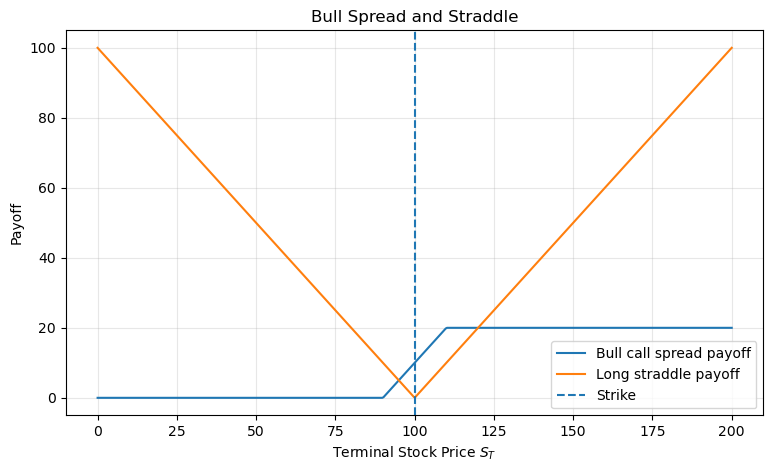

In [5]:
# Strategy payoff diagrams

K1 = 90
K2 = 110
K = 100

covered_call = S - np.maximum(S - K, 0)
protective_put = S + np.maximum(K - S, 0)
bull_spread = np.maximum(S - K1, 0) - np.maximum(S - K2, 0)
straddle = np.maximum(S - K, 0) + np.maximum(K - S, 0)

plt.figure(figsize=(9, 5))
plt.plot(S, covered_call, label="Covered call payoff")
plt.plot(S, protective_put, label="Protective put payoff")
plt.axvline(K, linestyle="--", label="Strike")
plt.title("Covered Call and Protective Put")
plt.xlabel("Terminal Stock Price $S_T$")
plt.ylabel("Payoff")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(S, bull_spread, label="Bull call spread payoff")
plt.plot(S, straddle, label="Long straddle payoff")
plt.axvline(K, linestyle="--", label="Strike")
plt.title("Bull Spread and Straddle")
plt.xlabel("Terminal Stock Price $S_T$")
plt.ylabel("Payoff")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 4. Put-Call Parity

For European options on a non-dividend-paying stock, put-call parity is

$$
C_0 - P_0 = S_0 - Ke^{-rT}.
$$

Equivalently,

$$
C_0 + Ke^{-rT} = P_0 + S_0.
$$

The left side is:

1. Buy a call.
2. Buy a risk-free bond that pays $K$ at expiration.

The right side is:

1. Buy a put.
2. Buy the stock.

At expiration:

If $S_T>K$, the left side pays $S_T-K+K=S_T$, and the right side pays $0+S_T=S_T$.

If $S_T<K$, the left side pays $0+K=K$, and the right side pays $K-S_T+S_T=K$.

The two portfolios have the same payoff in every state. By no arbitrage, they must have the same price today.

With continuous dividend yield $q$, parity becomes

$$
C_0 - P_0 = S_0e^{-qT}-Ke^{-rT}.
$$

In [7]:
# Put-call parity check

S0 = 100
K = 100
r = 0.04
T = 1
q = 0.00

call_price_example = 10.5
put_from_parity = call_price_example - S0*np.exp(-q*T) + K*np.exp(-r*T)

print(f"Given call price: {call_price_example:.2f}")
print(f"Put price implied by put-call parity: {put_from_parity:.2f}")

# Arbitrage check
observed_put = 4.0
parity_gap = call_price_example - observed_put - (S0*np.exp(-q*T) - K*np.exp(-r*T))
print(f"Parity gap C - P - (S - PV(K)): {parity_gap:.4f}")

Given call price: 10.50
Put price implied by put-call parity: 6.58
Parity gap C - P - (S - PV(K)): 2.5789


## 5. One-Period Binomial Model

The binomial model is the cleanest way to see no-arbitrage option pricing.

Suppose the current stock price is $S_0$. One period later, the stock can move up or down:

$$
S_u = uS_0,
$$

$$
S_d = dS_0,
$$

where $u>1$ and $d<1$.

Let the risk-free gross return be

$$
R=e^{r\Delta t}.
$$

No arbitrage requires

$$
d < R < u.
$$

A call option has future payoffs:

$$
C_u = \max(uS_0-K,0),
$$

$$
C_d = \max(dS_0-K,0).
$$

We construct a replicating portfolio with $\Delta$ shares of stock and $B$ dollars in the risk-free bond:

$$
\Delta uS_0 + BR = C_u,
$$

$$
\Delta dS_0 + BR = C_d.
$$

Subtracting gives

$$
\Delta = \frac{C_u-C_d}{S_0(u-d)}.
$$

Then

$$
B = \frac{C_d-\Delta dS_0}{R}.
$$

The option price is

$$
C_0 = \Delta S_0+B.
$$

Equivalently, define the risk-neutral probability

$$
p^*=\frac{R-d}{u-d}.
$$

Then

$$
C_0=e^{-r\Delta t}\left[p^*C_u+(1-p^*)C_d\right].
$$

In [9]:
# One-period binomial model

def one_period_binomial_call(S0, K, r, dt, u, d):
    R = np.exp(r * dt)
    Cu = max(u*S0 - K, 0)
    Cd = max(d*S0 - K, 0)
    delta = (Cu - Cd) / (S0 * (u - d))
    B = (Cd - delta * d * S0) / R
    price_replication = delta * S0 + B
    p_star = (R - d) / (u - d)
    price_rn = np.exp(-r * dt) * (p_star * Cu + (1 - p_star) * Cd)
    return {
        "Cu": Cu, "Cd": Cd, "Delta": delta, "Bond": B,
        "Risk-neutral probability": p_star,
        "Replication price": price_replication,
        "Risk-neutral price": price_rn
    }

one_period_binomial_call(S0=100, K=100, r=0.05, dt=1, u=1.25, d=0.85)

{'Cu': 25.0,
 'Cd': 0,
 'Delta': 0.625,
 'Bond': -50.53406317660043,
 'Risk-neutral probability': 0.5031777409400603,
 'Replication price': 11.965936823399574,
 'Risk-neutral price': 11.965936823399572}

## 6. Multi-Period Binomial Model

The Cox-Ross-Rubinstein binomial model chooses

$$
u=e^{\sigma\sqrt{\Delta t}},
$$

$$
d=e^{-\sigma\sqrt{\Delta t}}=\frac{1}{u}.
$$

The risk-neutral probability is

$$
p^*=\frac{e^{r\Delta t}-d}{u-d}.
$$

The model creates a recombining tree. At maturity, compute option payoffs. Then step backward through the tree using

$$
V_{t}
=
e^{-r\Delta t}
\left[
p^* V_{u,t+\Delta t}
+
(1-p^*) V_{d,t+\Delta t}
\right].
$$

For an American option, early exercise can be handled by taking the maximum of continuation value and exercise value at each node.

In [11]:
# Multi-period binomial option pricing

def binomial_option_price(S0, K, r, sigma, T, N, option_type="call", american=False):
    dt = T / N
    u = np.exp(sigma * np.sqrt(dt))
    d = 1 / u
    disc = np.exp(-r * dt)
    p = (np.exp(r * dt) - d) / (u - d)

    # terminal prices
    j = np.arange(N + 1)
    S_T = S0 * (u ** j) * (d ** (N - j))

    if option_type == "call":
        values = np.maximum(S_T - K, 0)
    else:
        values = np.maximum(K - S_T, 0)

    # backward induction
    for n in range(N - 1, -1, -1):
        values = disc * (p * values[1:] + (1 - p) * values[:-1])
        if american:
            j = np.arange(n + 1)
            S_n = S0 * (u ** j) * (d ** (n - j))
            if option_type == "call":
                exercise = np.maximum(S_n - K, 0)
            else:
                exercise = np.maximum(K - S_n, 0)
            values = np.maximum(values, exercise)

    return values[0]

for N in [1, 2, 5, 25, 100, 500]:
    price = binomial_option_price(100, 100, 0.05, 0.20, 1, N, "call")
    print(f"N={N:>3}: call price = {price:.4f}")

N=  1: call price = 12.1623
N=  2: call price = 9.5405
N=  5: call price = 10.8059
N= 25: call price = 10.5210
N=100: call price = 10.4306
N=500: call price = 10.4466


## 7. Stochastic Calculus: Brownian Motion and Geometric Brownian Motion

Option pricing models usually begin with a stochastic process for the underlying asset.

A **Brownian motion** or **Wiener process** $W_t$ has:

1. $W_0=0$.
2. Independent increments.
3. Normally distributed increments:

$$
W_{t+\Delta t}-W_t \sim N(0,\Delta t).
$$

4. Continuous paths.

The standard Black-Scholes model assumes stock prices follow **geometric Brownian motion**:

$$
dS_t = \mu S_t dt + \sigma S_t dW_t.
$$

Here:

- $\mu$ is the physical expected return.
- $\sigma$ is volatility.
- $dW_t$ is a Brownian shock.

The solution is

$$
S_T = S_0 \exp\left[\left(\mu-\frac{1}{2}\sigma^2\right)T+\sigma W_T\right].
$$

Thus, stock prices are lognormally distributed.

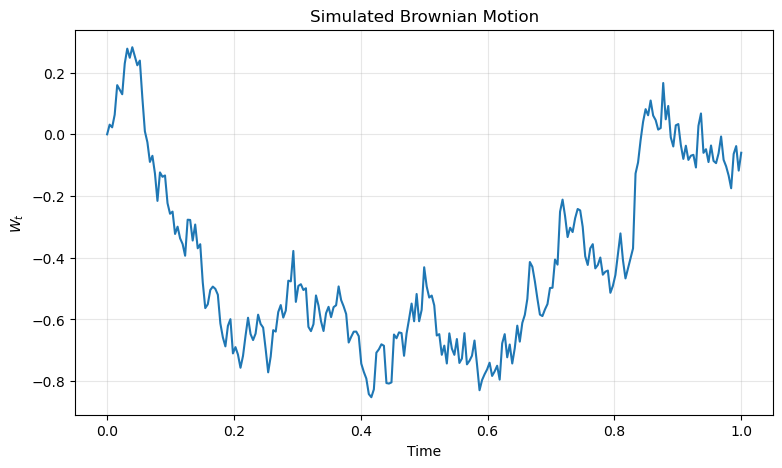

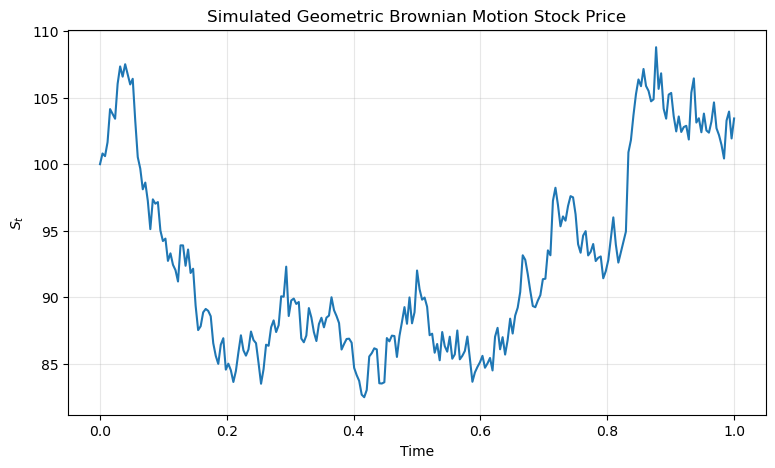

In [13]:
# Simulate Brownian motion and geometric Brownian motion

T = 1
N = 252
dt = T / N
mu = 0.08
sigma = 0.25
S0 = 100

time = np.linspace(0, T, N + 1)
dW = np.random.normal(0, np.sqrt(dt), size=N)
W = np.r_[0, np.cumsum(dW)]

S_path = S0 * np.exp((mu - 0.5*sigma**2)*time + sigma*W)

plt.figure(figsize=(9, 5))
plt.plot(time, W)
plt.title("Simulated Brownian Motion")
plt.xlabel("Time")
plt.ylabel("$W_t$")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(time, S_path)
plt.title("Simulated Geometric Brownian Motion Stock Price")
plt.xlabel("Time")
plt.ylabel("$S_t$")
plt.grid(True, alpha=0.3)
plt.show()

## 8. Itô's Lemma

In ordinary calculus, if $y=f(x)$, then

$$
dy=f'(x)dx.
$$

In stochastic calculus, the rule changes because Brownian increments satisfy

$$
(dW_t)^2 = dt.
$$

Let $S_t$ follow

$$
dS_t=\mu S_tdt+\sigma S_tdW_t.
$$

Let an option price be a smooth function

$$
V=V(S,t).
$$

Itô's lemma gives

$$
dV
=
\frac{\partial V}{\partial t}dt
+
\frac{\partial V}{\partial S}dS
+
\frac{1}{2}
\frac{\partial^2 V}{\partial S^2}
(dS)^2.
$$

Since

$$
(dS)^2 = \sigma^2S^2dt,
$$

we get

$$
dV
=
\left(
V_t+\mu S V_S+\frac{1}{2}\sigma^2S^2V_{SS}
\right)dt
+
\sigma S V_S dW_t.
$$

The second derivative term is not optional. It is the mathematical reason convexity matters in option pricing.

## 9. The Black-Scholes PDE

Let $V(S,t)$ be the option price. A delta-hedged portfolio is formed by holding one option and shorting $\Delta$ shares of stock:

$$
\Pi = V - \Delta S.
$$

Using Itô's lemma,

$$
dV
=
\left(
V_t+\mu S V_S+\frac{1}{2}\sigma^2S^2V_{SS}
\right)dt
+
\sigma S V_S dW_t.
$$

The stock process is

$$
dS=\mu Sdt+\sigma SdW_t.
$$

The portfolio change is

$$
d\Pi=dV-\Delta dS.
$$

Choose

$$
\Delta=V_S.
$$

Then the random $dW_t$ term disappears. The hedged portfolio is locally riskless, so it must earn the risk-free rate:

$$
d\Pi=r\Pi dt.
$$

Substituting and simplifying yields the Black-Scholes partial differential equation:

$$
V_t+\frac{1}{2}\sigma^2S^2V_{SS}+rSV_S-rV=0.
$$

For a European call, the terminal condition is

$$
V(S,T)=\max(S-K,0).
$$

For a European put,

$$
V(S,T)=\max(K-S,0).
$$

Notice that $\mu$ disappears. The expected return of the stock does not enter the Black-Scholes option price because the risk can be dynamically hedged.

## 10. Risk-Neutral Pricing

Risk-neutral pricing says the option price equals the discounted expected payoff under a risk-neutral probability measure $Q$:

$$
V_0 = e^{-rT}E^Q[\text{Payoff}(S_T)].
$$

Under the physical measure $P$,

$$
dS_t = \mu S_tdt+\sigma S_tdW_t^P.
$$

Under the risk-neutral measure $Q$,

$$
dS_t = rS_tdt+\sigma S_tdW_t^Q.
$$

If the stock pays a continuous dividend yield $q$, the risk-neutral drift becomes

$$
r-q.
$$

Risk-neutral pricing does not assume investors are actually risk-neutral. It is a no-arbitrage pricing transformation. Risk preferences are embedded in market prices, and the transformed probabilities price assets as if expected returns were the risk-free rate after appropriate adjustments.

## 11. The Black-Scholes Formula

For a non-dividend-paying stock, the European call price is

$$
C = S_0N(d_1)-Ke^{-rT}N(d_2),
$$

where

$$
d_1=
\frac{\ln(S_0/K)+(r+\frac{1}{2}\sigma^2)T}{\sigma\sqrt{T}},
$$

and

$$
d_2=d_1-\sigma\sqrt{T}.
$$

The European put price is

$$
P = Ke^{-rT}N(-d_2)-S_0N(-d_1).
$$

With continuous dividend yield $q$:

$$
C = S_0e^{-qT}N(d_1)-Ke^{-rT}N(d_2),
$$

$$
P = Ke^{-rT}N(-d_2)-S_0e^{-qT}N(-d_1),
$$

where

$$
d_1=
\frac{\ln(S_0/K)+(r-q+\frac{1}{2}\sigma^2)T}{\sigma\sqrt{T}},
$$

$$
d_2=d_1-\sigma\sqrt{T}.
$$

In [15]:
# Black-Scholes formula

def bs_price(S, K, r, sigma, T, q=0.0, option_type="call"):
    if T <= 0:
        if option_type == "call":
            return max(S - K, 0)
        return max(K - S, 0)

    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    if option_type == "call":
        return S*np.exp(-q*T)*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)
    else:
        return K*np.exp(-r*T)*norm.cdf(-d2) - S*np.exp(-q*T)*norm.cdf(-d1)

S0 = 100
K = 100
r = 0.05
sigma = 0.20
T = 1

call_bs = bs_price(S0, K, r, sigma, T, option_type="call")
put_bs = bs_price(S0, K, r, sigma, T, option_type="put")

print(f"Black-Scholes call price: {call_bs:.4f}")
print(f"Black-Scholes put price: {put_bs:.4f}")
print(f"Put-call parity check: C - P = {call_bs - put_bs:.4f}, S - PV(K) = {S0 - K*np.exp(-r*T):.4f}")

Black-Scholes call price: 10.4506
Black-Scholes put price: 5.5735
Put-call parity check: C - P = 4.8771, S - PV(K) = 4.8771


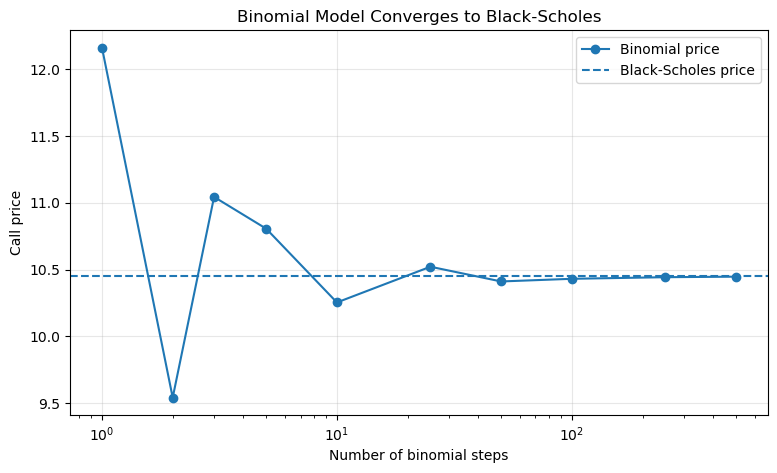

In [17]:
# Compare binomial prices to Black-Scholes

Ns = np.array([1, 2, 3, 5, 10, 25, 50, 100, 250, 500])
binomial_prices = np.array([binomial_option_price(S0, K, r, sigma, T, int(N), "call") for N in Ns])

plt.figure(figsize=(9, 5))
plt.plot(Ns, binomial_prices, marker="o", label="Binomial price")
plt.axhline(call_bs, linestyle="--", label="Black-Scholes price")
plt.xscale("log")
plt.title("Binomial Model Converges to Black-Scholes")
plt.xlabel("Number of binomial steps")
plt.ylabel("Call price")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 12. Dynamic Hedging

The Black-Scholes derivation relies on dynamic hedging. The option's delta is

$$
\Delta = \frac{\partial V}{\partial S}.
$$

A delta-hedged position adjusts the stock holding so that small changes in the underlying stock price have little first-order effect on portfolio value.

For a European call with continuous dividend yield $q$,

$$
\Delta_C = e^{-qT}N(d_1).
$$

For a European put,

$$
\Delta_P = e^{-qT}(N(d_1)-1).
$$

Because delta changes as $S$, $T$, and $\sigma$ change, hedging must be updated over time. Dynamic hedging is not costless in the real world. Transaction costs, discrete rebalancing, jumps, and volatility changes create hedging error.

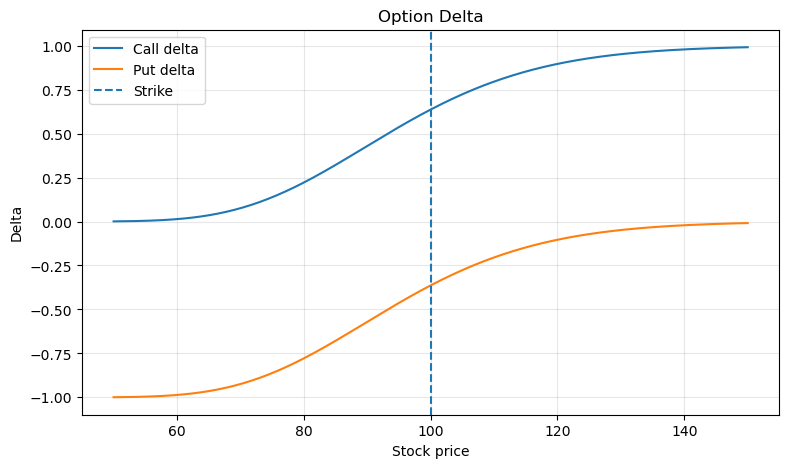

In [19]:
# Delta as a function of stock price

def bs_greeks(S, K, r, sigma, T, q=0.0, option_type="call"):
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    pdf_d1 = norm.pdf(d1)

    if option_type == "call":
        delta = np.exp(-q*T) * norm.cdf(d1)
        theta = (
            -S*np.exp(-q*T)*pdf_d1*sigma/(2*np.sqrt(T))
            - r*K*np.exp(-r*T)*norm.cdf(d2)
            + q*S*np.exp(-q*T)*norm.cdf(d1)
        )
        rho = K*T*np.exp(-r*T)*norm.cdf(d2)
    else:
        delta = np.exp(-q*T) * (norm.cdf(d1) - 1)
        theta = (
            -S*np.exp(-q*T)*pdf_d1*sigma/(2*np.sqrt(T))
            + r*K*np.exp(-r*T)*norm.cdf(-d2)
            - q*S*np.exp(-q*T)*norm.cdf(-d1)
        )
        rho = -K*T*np.exp(-r*T)*norm.cdf(-d2)

    gamma = np.exp(-q*T) * pdf_d1 / (S * sigma * np.sqrt(T))
    vega = S*np.exp(-q*T)*pdf_d1*np.sqrt(T)

    return {"delta": delta, "gamma": gamma, "vega": vega, "theta": theta, "rho": rho}

S_grid = np.linspace(50, 150, 300)
call_delta = np.array([bs_greeks(s, K, r, sigma, T, option_type="call")["delta"] for s in S_grid])
put_delta = np.array([bs_greeks(s, K, r, sigma, T, option_type="put")["delta"] for s in S_grid])

plt.figure(figsize=(9, 5))
plt.plot(S_grid, call_delta, label="Call delta")
plt.plot(S_grid, put_delta, label="Put delta")
plt.axvline(K, linestyle="--", label="Strike")
plt.title("Option Delta")
plt.xlabel("Stock price")
plt.ylabel("Delta")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 13. The Greeks

The Greeks measure option-price sensitivities.

### Delta

$$
\Delta=\frac{\partial V}{\partial S}.
$$

Delta measures sensitivity to the underlying price.

### Gamma

$$
\Gamma=\frac{\partial^2 V}{\partial S^2}.
$$

Gamma measures the curvature of the option price with respect to the underlying price. High gamma means delta changes quickly.

### Vega

$$
\nu=\frac{\partial V}{\partial \sigma}.
$$

Vega measures sensitivity to volatility.

### Theta

$$
\Theta=\frac{\partial V}{\partial t}.
$$

Theta measures sensitivity to the passage of time.

### Rho

$$
\rho=\frac{\partial V}{\partial r}.
$$

Rho measures sensitivity to the risk-free rate.

The Greeks are essential for hedging, risk management, and market making.

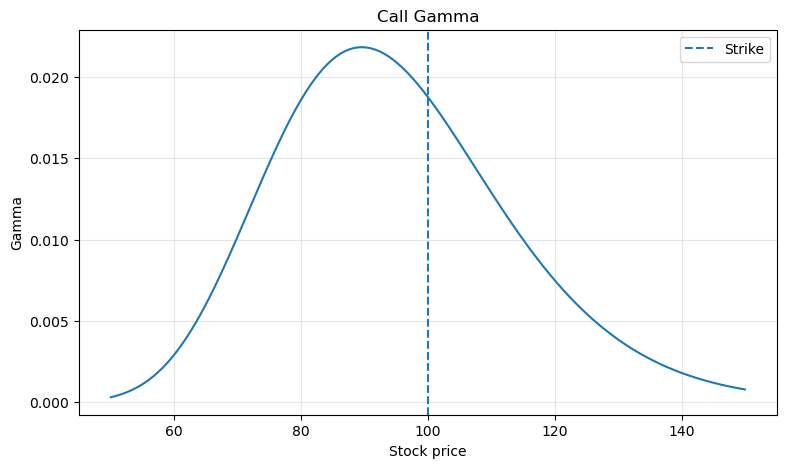

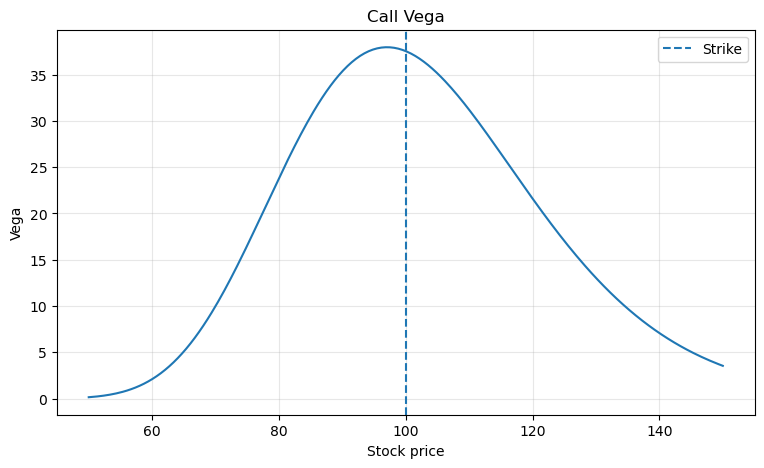

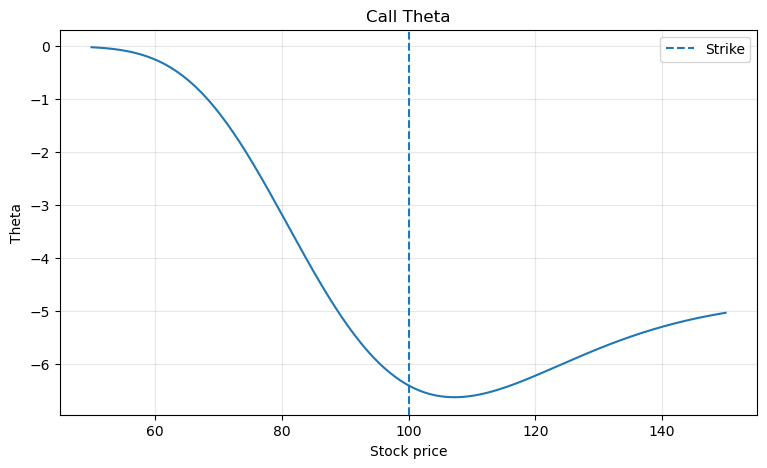

In [21]:
# Plot several Greeks for a call

call_gamma = np.array([bs_greeks(s, K, r, sigma, T, option_type="call")["gamma"] for s in S_grid])
call_vega = np.array([bs_greeks(s, K, r, sigma, T, option_type="call")["vega"] for s in S_grid])
call_theta = np.array([bs_greeks(s, K, r, sigma, T, option_type="call")["theta"] for s in S_grid])

plt.figure(figsize=(9, 5))
plt.plot(S_grid, call_gamma)
plt.axvline(K, linestyle="--", label="Strike")
plt.title("Call Gamma")
plt.xlabel("Stock price")
plt.ylabel("Gamma")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(S_grid, call_vega)
plt.axvline(K, linestyle="--", label="Strike")
plt.title("Call Vega")
plt.xlabel("Stock price")
plt.ylabel("Vega")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(S_grid, call_theta)
plt.axvline(K, linestyle="--", label="Strike")
plt.title("Call Theta")
plt.xlabel("Stock price")
plt.ylabel("Theta")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 14. Implied Volatility

The Black-Scholes formula maps volatility to option price:

$$
C = BS(S,K,r,\sigma,T).
$$

Market prices are observed. Volatility is not directly observed. The **implied volatility** is the value of $\sigma$ that makes the model price equal the market price:

$$
C_{market}=BS(S,K,r,\sigma_{imp},T).
$$

Thus,

$$
\sigma_{imp}
=
BS^{-1}(C_{market}).
$$

Implied volatility is not a forecast from the model alone. It is the volatility input implied by market prices under a chosen pricing model.

In [23]:
# Implied volatility solver

def implied_volatility(price, S, K, r, T, q=0.0, option_type="call"):
    def objective(sig):
        return bs_price(S, K, r, sig, T, q, option_type) - price

    try:
        return brentq(objective, 1e-6, 5.0)
    except ValueError:
        return np.nan

market_call_price = 10.45
iv = implied_volatility(market_call_price, S0, K, r, T, option_type="call")

print(f"Market call price: {market_call_price:.2f}")
print(f"Implied volatility: {iv:.2%}")
print(f"Black-Scholes price using implied volatility: {bs_price(S0, K, r, iv, T):.4f}")

Market call price: 10.45
Implied volatility: 20.00%
Black-Scholes price using implied volatility: 10.4500


## 15. Implied Volatility Smile, Skew, and Surface

If Black-Scholes assumptions were exactly correct, all options on the same underlying with the same maturity would have the same implied volatility.

In real markets, implied volatility varies by strike and maturity.

### Volatility smile

Implied volatility is often higher for deep in-the-money and deep out-of-the-money options than for at-the-money options.

### Volatility skew

Equity index options often show higher implied volatility for low-strike puts. This reflects crash risk, demand for downside protection, and non-normal return distributions.

### Volatility surface

The implied volatility surface is a function of strike and maturity:

$$
\sigma_{imp}=\sigma_{imp}(K,T).
$$

The surface summarizes market prices across the option chain.

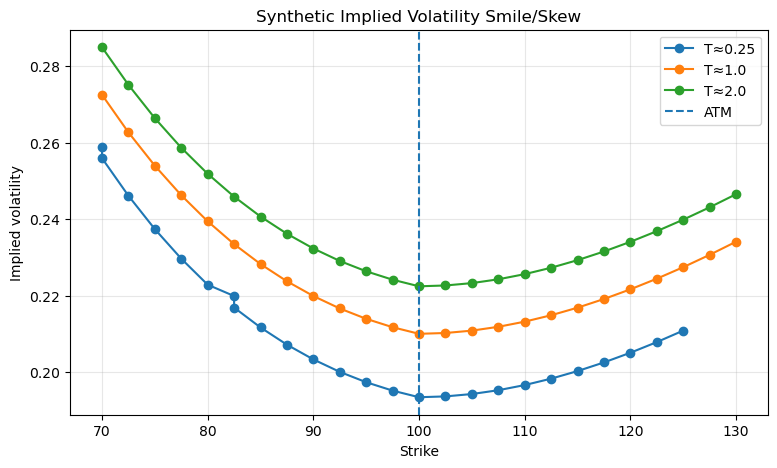

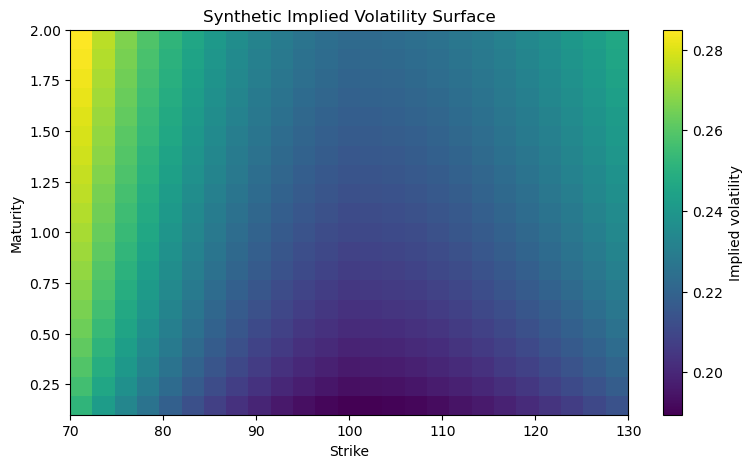

In [25]:
# Synthetic implied volatility surface

strikes = np.linspace(70, 130, 25)
maturities = np.linspace(0.1, 2.0, 20)

surface_rows = []
for T_i in maturities:
    for K_i in strikes:
        moneyness = K_i / S0
        implied_vol = (
            0.18
            + 0.35 * (np.log(moneyness))**2
            + 0.06 * max(0, 1 - moneyness)
            + 0.03 * np.sqrt(T_i)
        )
        surface_rows.append({"K": K_i, "T": T_i, "implied_vol": implied_vol})

iv_surface = pd.DataFrame(surface_rows)

# Plot smile for selected maturities
plt.figure(figsize=(9, 5))
for T_i in [0.25, 1.0, 2.0]:
    subset = iv_surface.iloc[(iv_surface["T"] - T_i).abs().argsort()[:len(strikes)]].sort_values("K")
    plt.plot(subset["K"], subset["implied_vol"], marker="o", label=f"T≈{T_i}")
plt.axvline(S0, linestyle="--", label="ATM")
plt.title("Synthetic Implied Volatility Smile/Skew")
plt.xlabel("Strike")
plt.ylabel("Implied volatility")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Heatmap-style surface without seaborn
pivot = iv_surface.pivot(index="T", columns="K", values="implied_vol")
plt.figure(figsize=(9, 5))
plt.imshow(pivot.values, aspect="auto", origin="lower",
           extent=[strikes.min(), strikes.max(), maturities.min(), maturities.max()])
plt.colorbar(label="Implied volatility")
plt.title("Synthetic Implied Volatility Surface")
plt.xlabel("Strike")
plt.ylabel("Maturity")
plt.show()

## 16. Monte Carlo Option Pricing

Under the risk-neutral measure,

$$
dS_t = rS_tdt+\sigma S_tdW_t^Q.
$$

The exact simulation at maturity is

$$
S_T = S_0\exp\left[\left(r-q-\frac{1}{2}\sigma^2\right)T+\sigma\sqrt{T}Z\right],
$$

where

$$
Z\sim N(0,1).
$$

Then a European call price can be estimated as

$$
\hat{C}_0
=
e^{-rT}
\frac{1}{M}
\sum_{m=1}^M
\max(S_T^{(m)}-K,0).
$$

Monte Carlo is flexible. It can handle path-dependent payoffs, stochastic volatility, jumps, and high-dimensional problems. Its main weakness is simulation error.

In [27]:
# Monte Carlo pricing for a European call

def monte_carlo_european_call(S0, K, r, sigma, T, q=0.0, n_sims=100000, seed=42):
    rng = np.random.default_rng(seed)
    Z = rng.normal(size=n_sims)
    ST = S0 * np.exp((r - q - 0.5*sigma**2)*T + sigma*np.sqrt(T)*Z)
    payoff = np.maximum(ST - K, 0)
    price = np.exp(-r*T) * payoff.mean()
    se = np.exp(-r*T) * payoff.std(ddof=1) / np.sqrt(n_sims)
    return price, se

mc_price, mc_se = monte_carlo_european_call(S0, K, r, sigma, T, n_sims=200000)

print(f"Monte Carlo call price: {mc_price:.4f}")
print(f"Monte Carlo standard error: {mc_se:.4f}")
print(f"Black-Scholes call price: {call_bs:.4f}")

Monte Carlo call price: 10.4634
Monte Carlo standard error: 0.0331
Black-Scholes call price: 10.4506


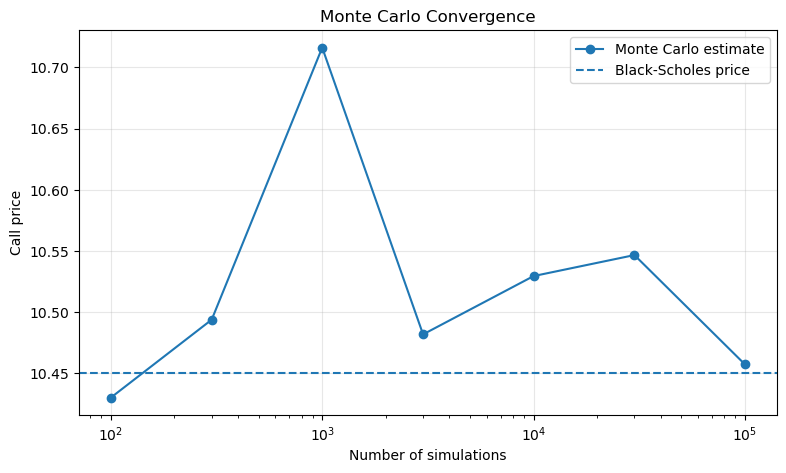

In [29]:
# Convergence of Monte Carlo estimate

sample_sizes = np.array([100, 300, 1000, 3000, 10000, 30000, 100000])
mc_estimates = []
mc_errors = []

for m in sample_sizes:
    price_m, se_m = monte_carlo_european_call(S0, K, r, sigma, T, n_sims=int(m), seed=123)
    mc_estimates.append(price_m)
    mc_errors.append(se_m)

plt.figure(figsize=(9, 5))
plt.plot(sample_sizes, mc_estimates, marker="o", label="Monte Carlo estimate")
plt.axhline(call_bs, linestyle="--", label="Black-Scholes price")
plt.xscale("log")
plt.title("Monte Carlo Convergence")
plt.xlabel("Number of simulations")
plt.ylabel("Call price")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 17. Path-Dependent Options

Monte Carlo is especially useful for path-dependent options.

An **Asian call option** pays based on the average stock price:

$$
\max(\bar{S}-K,0),
$$

where

$$
\bar{S}=\frac{1}{N}\sum_{j=1}^N S_{t_j}.
$$

Because the payoff depends on the path, not only $S_T$, the Black-Scholes closed-form formula is generally not enough. Simulation becomes natural.

In [31]:
# Monte Carlo Asian call option

def monte_carlo_asian_call(S0, K, r, sigma, T, q=0.0, n_steps=252, n_sims=50000, seed=42):
    rng = np.random.default_rng(seed)
    dt = T / n_steps
    Z = rng.normal(size=(n_sims, n_steps))
    increments = (r - q - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z
    log_paths = np.cumsum(increments, axis=1)
    S_paths = S0 * np.exp(log_paths)
    avg_S = S_paths.mean(axis=1)
    payoff = np.maximum(avg_S - K, 0)
    price = np.exp(-r*T) * payoff.mean()
    se = np.exp(-r*T) * payoff.std(ddof=1) / np.sqrt(n_sims)
    return price, se

asian_price, asian_se = monte_carlo_asian_call(S0, K, r, sigma, T)

print(f"Asian call Monte Carlo price: {asian_price:.4f}")
print(f"Standard error: {asian_se:.4f}")
print(f"European call price for comparison: {call_bs:.4f}")

Asian call Monte Carlo price: 5.7740
Standard error: 0.0358
European call price for comparison: 10.4506


## 18. Heston Stochastic Volatility Model

Black-Scholes assumes constant volatility. Market data show volatility changes over time and tends to cluster.

The Heston model allows volatility to be stochastic. It specifies

$$
dS_t = rS_tdt+\sqrt{v_t}S_tdW_t^S,
$$

and

$$
dv_t = \kappa(\theta-v_t)dt+\xi\sqrt{v_t}dW_t^v.
$$

The Brownian motions can be correlated:

$$
dW_t^SdW_t^v = \rho dt.
$$

Parameters:

- $v_t$: instantaneous variance.
- $\kappa$: speed of mean reversion.
- $\theta$: long-run variance.
- $\xi$: volatility of volatility.
- $\rho$: correlation between price shocks and volatility shocks.

Negative $\rho$ can generate equity-index volatility skew because negative stock returns tend to coincide with rising volatility.

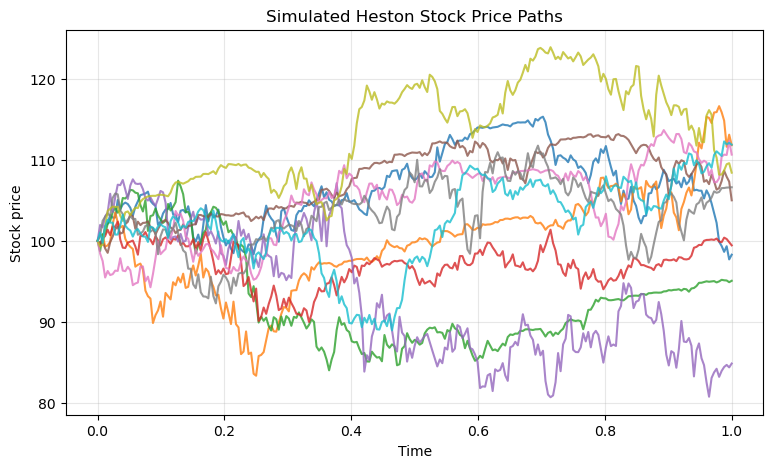

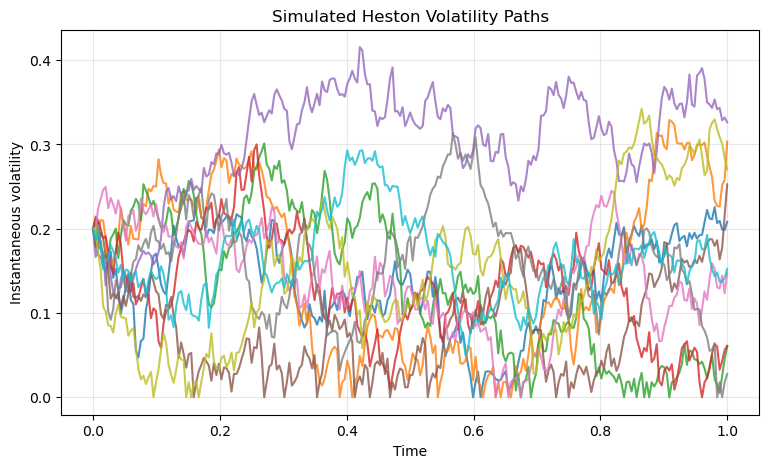

In [33]:
# Simulate Heston paths with Euler discretization and full truncation

def simulate_heston_paths(
    S0=100, v0=0.04, r=0.03, T=1, n_steps=252, n_sims=5000,
    kappa=2.0, theta=0.04, xi=0.5, rho=-0.7, seed=42
):
    rng = np.random.default_rng(seed)
    dt = T / n_steps

    S = np.zeros((n_sims, n_steps + 1))
    v = np.zeros((n_sims, n_steps + 1))
    S[:, 0] = S0
    v[:, 0] = v0

    for t in range(n_steps):
        z1 = rng.normal(size=n_sims)
        z2 = rng.normal(size=n_sims)
        z_v = z1
        z_s = rho*z1 + np.sqrt(1-rho**2)*z2

        v_pos = np.maximum(v[:, t], 0)
        v[:, t+1] = v[:, t] + kappa*(theta-v_pos)*dt + xi*np.sqrt(v_pos*dt)*z_v
        v[:, t+1] = np.maximum(v[:, t+1], 0)

        S[:, t+1] = S[:, t] * np.exp((r - 0.5*v_pos)*dt + np.sqrt(v_pos*dt)*z_s)

    return S, v

S_heston, v_heston = simulate_heston_paths()

plt.figure(figsize=(9, 5))
for i in range(10):
    plt.plot(np.linspace(0, 1, S_heston.shape[1]), S_heston[i], alpha=0.8)
plt.title("Simulated Heston Stock Price Paths")
plt.xlabel("Time")
plt.ylabel("Stock price")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(9, 5))
for i in range(10):
    plt.plot(np.linspace(0, 1, v_heston.shape[1]), np.sqrt(v_heston[i]), alpha=0.8)
plt.title("Simulated Heston Volatility Paths")
plt.xlabel("Time")
plt.ylabel("Instantaneous volatility")
plt.grid(True, alpha=0.3)
plt.show()

## 19. Merton Jump-Diffusion Model

Black-Scholes assumes continuous stock-price paths. Real markets can jump.

Merton's jump-diffusion model adds jumps to geometric Brownian motion:

$$
\frac{dS_t}{S_{t^-}}
=
(\mu-\lambda k)dt+\sigma dW_t+dJ_t.
$$

Here:

- $\lambda$ is jump intensity.
- $J_t$ is a compound Poisson jump process.
- Jump sizes are often assumed lognormal.
- $k=E[e^Y-1]$ is the expected percentage jump size if log jump size is $Y$.

Under a risk-neutral specification,

$$
S_T
=
S_0
\exp
\left[
\left(r-\lambda k-\frac{1}{2}\sigma^2\right)T
+
\sigma W_T
+
\sum_{j=1}^{N_T}Y_j
\right],
$$

where

$$
N_T\sim Poisson(\lambda T).
$$

Jumps help generate fat tails and implied-volatility smiles.

Merton jump-diffusion call price: 11.3933
Black-Scholes price with same diffusion volatility: 8.6407


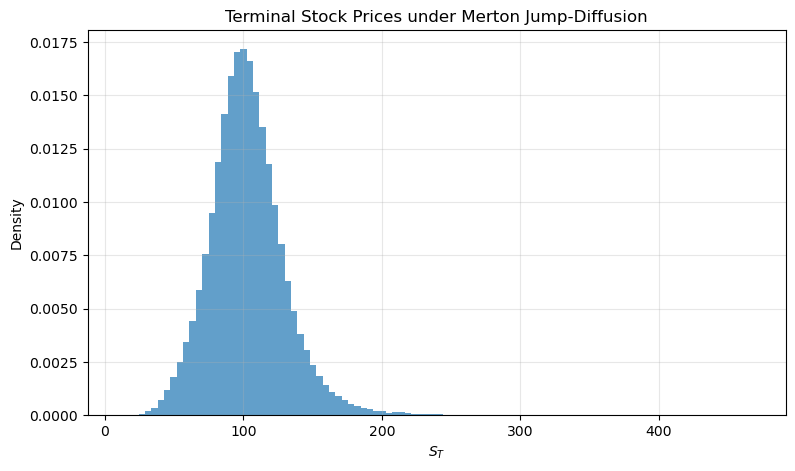

In [35]:
# Simulate Merton jump-diffusion terminal prices and price a call

def monte_carlo_merton_call(
    S0=100, K=100, r=0.03, sigma=0.18, T=1,
    lam=0.6, muJ=-0.08, sigmaJ=0.25,
    n_sims=200000, seed=42
):
    rng = np.random.default_rng(seed)
    N = rng.poisson(lam*T, size=n_sims)
    jump_sums = rng.normal(N*muJ, np.sqrt(N)*sigmaJ)
    k = np.exp(muJ + 0.5*sigmaJ**2) - 1

    Z = rng.normal(size=n_sims)
    ST = S0 * np.exp((r - lam*k - 0.5*sigma**2)*T + sigma*np.sqrt(T)*Z + jump_sums)
    payoff = np.maximum(ST - K, 0)
    price = np.exp(-r*T) * payoff.mean()
    return price, ST

merton_price, ST_merton = monte_carlo_merton_call()
bs_comparable = bs_price(100, 100, 0.03, 0.18, 1)

print(f"Merton jump-diffusion call price: {merton_price:.4f}")
print(f"Black-Scholes price with same diffusion volatility: {bs_comparable:.4f}")

plt.figure(figsize=(9, 5))
plt.hist(ST_merton, bins=100, density=True, alpha=0.7)
plt.title("Terminal Stock Prices under Merton Jump-Diffusion")
plt.xlabel("$S_T$")
plt.ylabel("Density")
plt.grid(True, alpha=0.3)
plt.show()

## 20. Calibration to Market Data

A model is useful only if it can fit market data well enough for the purpose at hand.

Calibration means choosing model parameters to minimize pricing errors.

Suppose we observe market option prices

$$
C_i^{market}
$$

for strikes and maturities indexed by $i$. A model with parameters $\theta$ produces prices

$$
C_i^{model}(\theta).
$$

A common calibration problem is

$$
\hat{\theta}
=
\arg\min_\theta
\sum_i
w_i
\left[
C_i^{model}(\theta)-C_i^{market}
\right]^2.
$$

The weights $w_i$ may reflect bid-ask spreads, vega, liquidity, or contract importance.

For Black-Scholes, one constant volatility usually cannot match all option prices. That failure is visible in the implied volatility surface. More advanced models try to fit the surface more accurately.

Calibrated constant Black-Scholes volatility: 18.50%


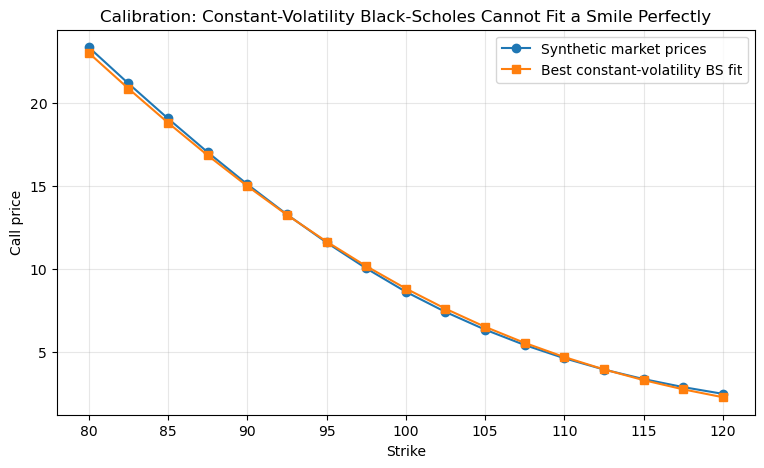

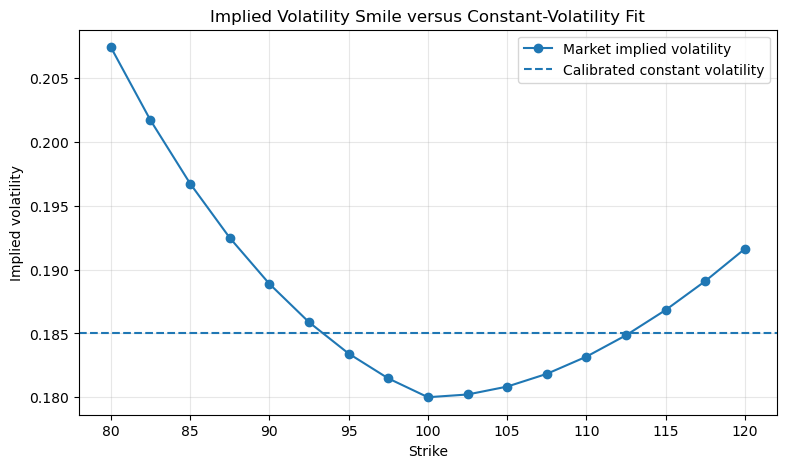

In [37]:
# Simple calibration example: choose one Black-Scholes volatility to fit synthetic market prices

# Create synthetic market option prices from a volatility skew
S0_cal = 100
r_cal = 0.03
T_cal = 1.0
K_grid = np.linspace(80, 120, 17)

true_market_ivs = 0.18 + 0.35*(np.log(K_grid/S0_cal))**2 + 0.05*np.maximum(0, 1 - K_grid/S0_cal)
market_prices = np.array([
    bs_price(S0_cal, K_i, r_cal, iv_i, T_cal, option_type="call")
    for K_i, iv_i in zip(K_grid, true_market_ivs)
])

def calibration_objective(params):
    sigma_guess = params[0]
    model_prices = np.array([
        bs_price(S0_cal, K_i, r_cal, sigma_guess, T_cal, option_type="call")
        for K_i in K_grid
    ])
    return np.mean((model_prices - market_prices)**2)

result = minimize(calibration_objective, x0=np.array([0.20]), bounds=[(0.01, 2.0)])
calibrated_sigma = result.x[0]

model_prices_calibrated = np.array([
    bs_price(S0_cal, K_i, r_cal, calibrated_sigma, T_cal, option_type="call")
    for K_i in K_grid
])

print(f"Calibrated constant Black-Scholes volatility: {calibrated_sigma:.2%}")

plt.figure(figsize=(9, 5))
plt.plot(K_grid, market_prices, marker="o", label="Synthetic market prices")
plt.plot(K_grid, model_prices_calibrated, marker="s", label="Best constant-volatility BS fit")
plt.title("Calibration: Constant-Volatility Black-Scholes Cannot Fit a Smile Perfectly")
plt.xlabel("Strike")
plt.ylabel("Call price")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

market_ivs_backed_out = np.array([
    implied_volatility(price, S0_cal, K_i, r_cal, T_cal, option_type="call")
    for price, K_i in zip(market_prices, K_grid)
])

plt.figure(figsize=(9, 5))
plt.plot(K_grid, market_ivs_backed_out, marker="o", label="Market implied volatility")
plt.axhline(calibrated_sigma, linestyle="--", label="Calibrated constant volatility")
plt.title("Implied Volatility Smile versus Constant-Volatility Fit")
plt.xlabel("Strike")
plt.ylabel("Implied volatility")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 21. Practical Model Risk

Every option pricing model makes simplifying assumptions.

Black-Scholes assumes:

- Continuous trading.
- Frictionless markets.
- Constant volatility.
- Continuous stock-price paths.
- Normally distributed log returns.
- No transaction costs.
- Perfect dynamic hedging.

Real markets have:

- Discrete hedging.
- Bid-ask spreads.
- Margin requirements.
- Stochastic volatility.
- Jumps.
- Liquidity shocks.
- Funding costs.
- Early exercise features.
- Dividends and borrow constraints.

More advanced models reduce some errors but introduce others. Heston adds stochastic volatility. Merton adds jumps. Local volatility models fit the implied volatility surface exactly at a point in time. Monte Carlo handles complex payoffs. Calibration improves fit to market prices.

But all models are approximations. A practitioner must ask:

1. What risks does the model capture?
2. What risks does it omit?
3. How stable are calibrated parameters?
4. How large is hedging error?
5. How sensitive is the price to volatility, rates, dividends, and jumps?
6. Is the model being used for pricing, hedging, risk management, or speculation?

## 22. Summary

This lecture introduced the main ideas in option pricing.

### Core option concepts

- Calls and puts are nonlinear claims.
- Payoff diagrams reveal state-contingent exposures.
- Option strategies combine primitive claims into custom risk profiles.
- Put-call parity follows from no arbitrage.

### No-arbitrage models

- The binomial model prices options by replication or risk-neutral probabilities.
- The Black-Scholes model arises from continuous-time dynamic hedging.
- Risk-neutral pricing discounts expected payoffs under a transformed probability measure.

### Stochastic calculus

- Brownian motion provides the shock process.
- Geometric Brownian motion models stock prices.
- Itô's lemma introduces the crucial second-derivative term.
- The Black-Scholes PDE follows from eliminating risk through delta hedging.

### Practical option analytics

- The Greeks measure option sensitivities.
- Implied volatility translates prices into volatility inputs.
- Volatility smiles and surfaces reveal failures of constant-volatility Black-Scholes.
- Heston and Merton extend the model with stochastic volatility and jumps.
- Monte Carlo simulation prices complex and path-dependent derivatives.
- Calibration chooses model parameters to fit market data.

The fundamental lesson is:

$$
\text{Option value} =
\text{discounted no-arbitrage value of a nonlinear payoff}.
$$